In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('../wo_types_comparison/wo_types_results.pkl', 'rb') as f:
    results1 = pickle.load(f)

with open('../w_types_comparison/w_types_results.pkl', 'rb') as f:
    results2 = pickle.load(f)

with open('../celltypeinitialized_comparison/celltypeinitialized_results.pkl', 'rb') as f:
    results3 = pickle.load(f)

with open('../DualMLP/dualmlps_results.pkl', 'rb') as f:
    results4 = pickle.load(f)

results = [results1, results2, results3, results4]

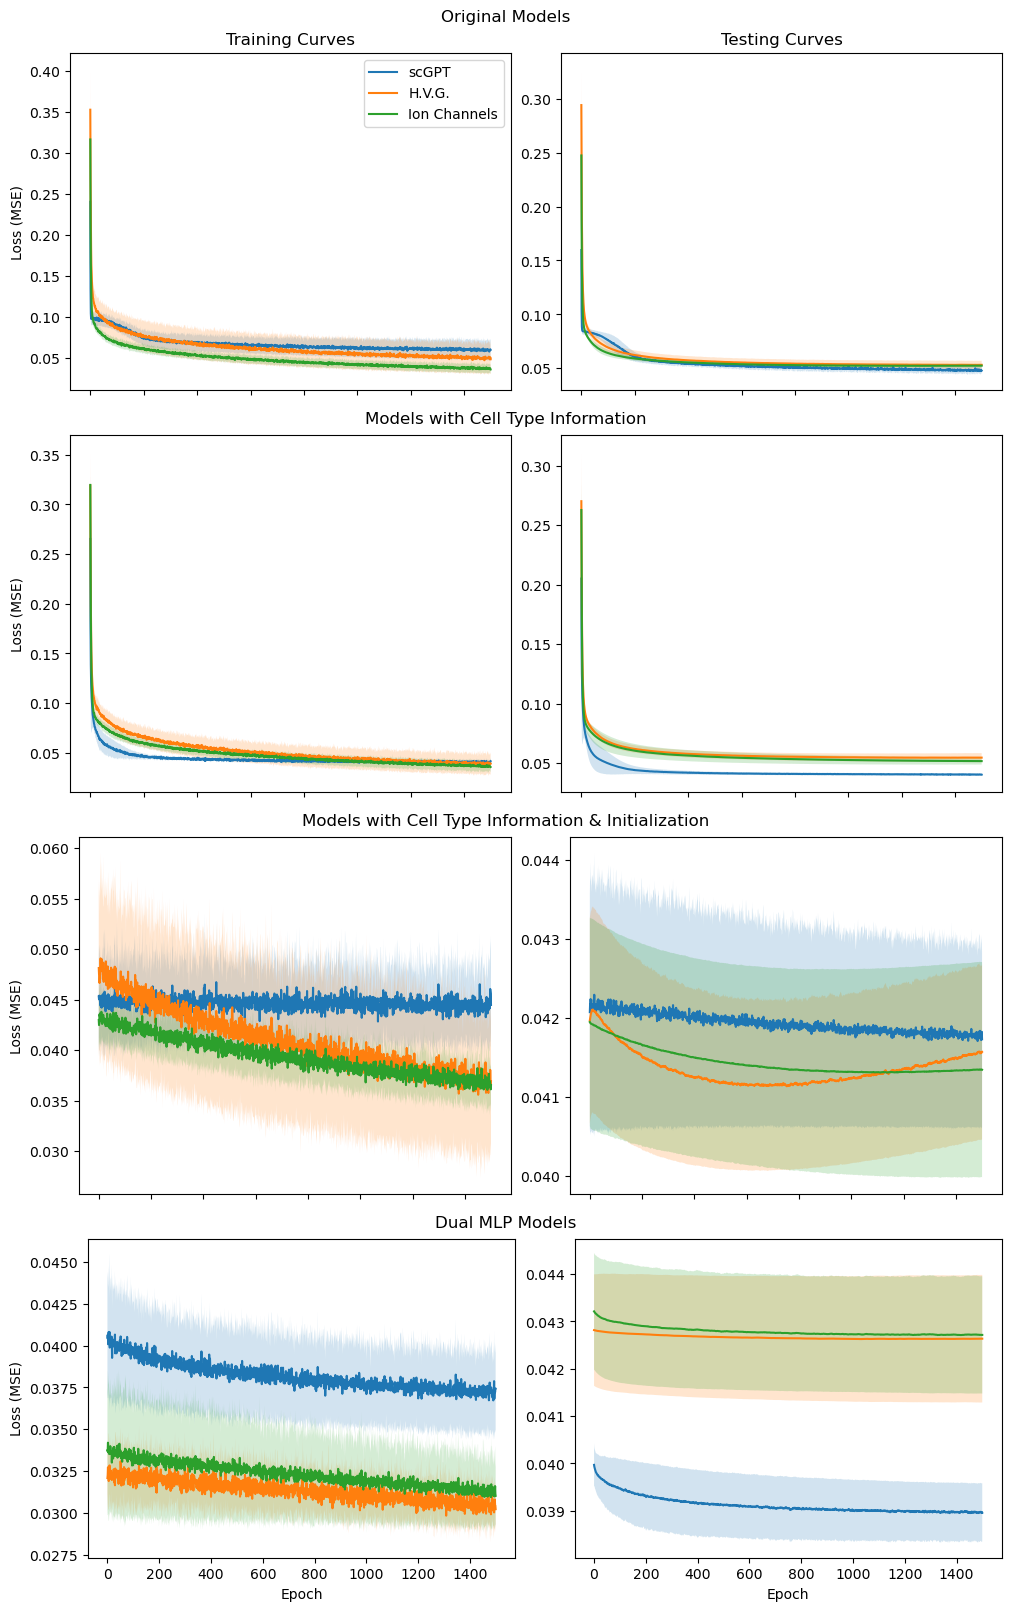

In [2]:
tests = ['Original Models', 'Models with Cell Type Information', 'Models with Cell Type Information & Initialization', 'Dual MLP Models']
models = ["scgpt", "hvg", "ion"]
labels = ["scGPT", "H.V.G.", "Ion Channels"]

fig = plt.figure(figsize=(10, 16), constrained_layout=True)
subfigs = fig.subfigures(nrows=4, ncols=1)

for i, subfig in enumerate(subfigs):
    subfig.suptitle(tests[i])
    axs = subfig.subplots(nrows=1, ncols=2)

    for j, model in enumerate(models):
        avg_losses = np.mean(results[i][model]["train_losses"], axis=0)
        std_losses = np.std(results[i][model]["train_losses"], axis=0)
        axs[0].plot(range(1500), avg_losses, label=labels[j])
        axs[0].fill_between(range(1500), avg_losses - std_losses, avg_losses + std_losses, alpha=0.2)
    axs[0].set_ylabel('Loss (MSE)')

    for j, model in enumerate(models):
        avg_losses = np.mean(results[i][model]["test_losses"], axis=0)
        std_losses = np.std(results[i][model]["test_losses"], axis=0)
        axs[1].plot(range(1500), avg_losses, label=labels[j])
        axs[1].fill_between(range(1500), avg_losses - std_losses, avg_losses + std_losses, alpha=0.2)
    
    if i == 0:
        axs[0].set_title("Training Curves")
        axs[1].set_title("Testing Curves")
        axs[0].legend()

    for ax in axs:
        if i == len(subfigs) - 1:
            ax.set_xlabel('Epoch')
        else:
            ax.tick_params(axis='x', labelbottom=False)

plt.savefig('learningcurves.pdf')
plt.show()

In [ ]:
shuffled_cell_indices1 = np.load('../wo_types_comparison/dualmlps_shuffled_cell_indices.npy')
shuffled_cell_indices = np.load('../DualMLP/dualmlps_shuffled_cell_indices.npy')